# Term-structure model examples

There are many different term-structure models. These can be fitted to the bootstrapped yields (see the examples in notebook `04_bootstrap.ipynb`) to form a full term-structure of interest rates. The term-structure models inherit of the `TermStructureABC` abstract base class. 

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantpy.math.curve import NelsonSiegel
from quantpy.math.curve import Svensson
from quantpy.math.curve import Anderson
from quantpy.math.curve import MultidynamicModel

plt.style.use('seaborn-v0_8')
example_root = Path(os.path.abspath(""))

In [2]:
bootstrap_date = "2026-03-06"

In [3]:
yield_df = pd.read_csv(example_root / "data" / f"fi_yields_{bootstrap_date}.csv")
yield_df.head(5)

,TimeToMaturity,ZeroYield
0,0.111111,0.017507
1,0.188889,0.018854
2,0.444444,0.020364
3,0.536111,0.020538
4,0.700000,0.021112


In [4]:
maturities = yield_df["TimeToMaturity"].to_numpy()
yields     = yield_df["ZeroYield"].to_numpy()

## Nelson-Siegel model

The Nelson-Siegel model is implemented in the `NelsonSiegel` class

In [5]:
model = NelsonSiegel(yields, maturities, method="dogbox", ftol=1e-7, xtol=1e-7, gtol=1e-7, max_nfev=10_000)

/home/kasper/GIT/quantpy/quantpy/math/curve/NelsonSiegel.py:18: RuntimeWarning: overflow encountered in exp
  return beta_0 + beta_1 * (1. - np.exp(-maturities / tau)) / (maturities / tau) \
/home/kasper/GIT/quantpy/quantpy/math/curve/NelsonSiegel.py:19: RuntimeWarning: overflow encountered in exp
  + beta_2 * ((1. - np.exp(-maturities / tau)) / (maturities / tau) - np.exp(-maturities / tau))
/home/kasper/GIT/quantpy/quantpy/math/curve/NelsonSiegel.py:19: RuntimeWarning: invalid value encountered in subtract
  + beta_2 * ((1. - np.exp(-maturities / tau)) / (maturities / tau) - np.exp(-maturities / tau))


In [6]:
print(model.params)

{'tau': np.float64(5.183868308401624), 'beta_0': np.float64(0.043405964598691296), 'beta_1': np.float64(-0.02432973571961596), 'beta_2': np.float64(-0.004477556209171735)}


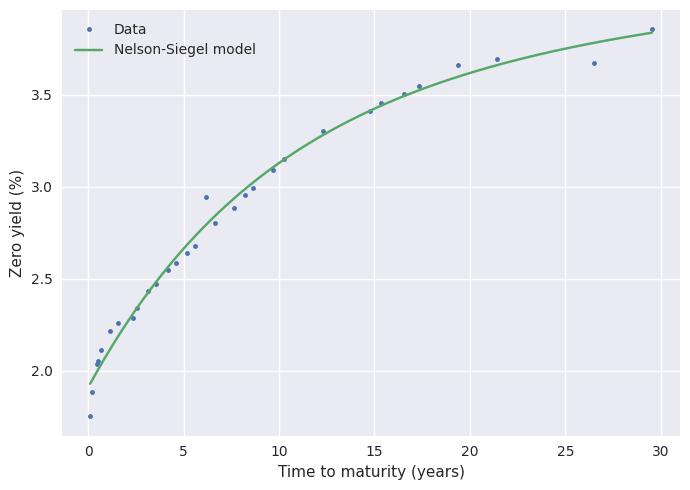

In [7]:
tt = np.linspace(maturities.min(), maturities.max(), 300)

fig = plt.figure(figsize=(7, 5))

plt.plot(maturities, yields * 100, '.', label="Data")
plt.plot(tt, model(tt) * 100, label="Nelson-Siegel model")
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

plt.legend()
fig.tight_layout()

plt.show()

## Svensson model

The Svensson model is implemented in the `Svensson` class

In [8]:
model = Svensson(yields, maturities, init_params=[5.18, 1, 0.043, -0.024, -0.0044, 1], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=10_000)

In [9]:
print(model.params)

{'tau_1': np.float64(9.563749684883998), 'tau_2': np.float64(0.4486409411315288), 'beta_0': np.float64(0.039509421747305845), 'beta_1': np.float64(-0.023217752444119492), 'beta_2': np.float64(0.021216844138918795), 'beta_3': np.float64(0.011379938723494208)}


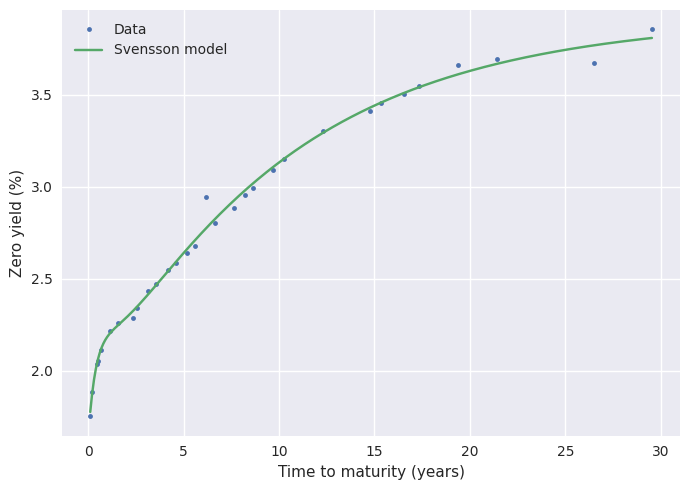

In [10]:
tt = np.linspace(maturities.min(), maturities.max(), 300)

fig = plt.figure(figsize=(7, 5))

plt.plot(maturities, yields * 100, '.', label="Data")
plt.plot(tt, model(tt) * 100, label="Svensson model")
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

plt.legend()
fig.tight_layout()

plt.show()

## Anderson method

Anderson method differs from the above models, by utilizing a smoothing spline with varying penalty term. Since Anderson and Sleath do not provide the coefficients for the penalty function, those have to be (roughly) estimated

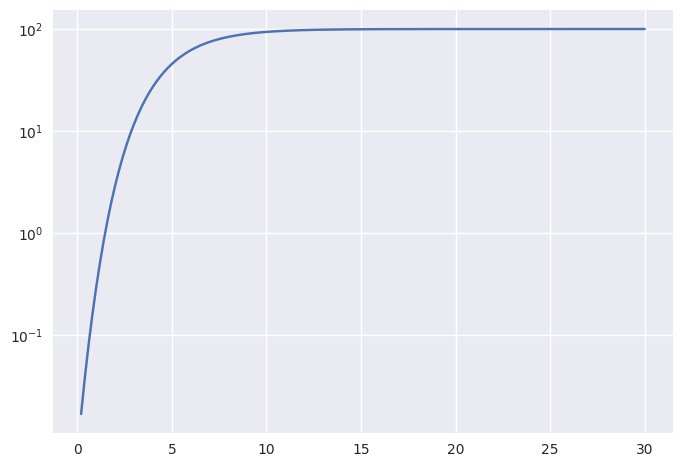

In [11]:
tt = np.linspace(0.2, 30, 300)

L = 4.6
S = -5
i = 2

plt.plot(tt, np.exp(L - (L - S) * np.exp(-tt / i)))
plt.yscale('log')

plt.show()

### Basis spline example

In [12]:
def b_spline_elem(order: int, knots: list[float]) -> callable:
  assert len(knots) == order + 2
  assert knots == sorted(knots)
  
  if order == 0:
    return lambda x: 1 if (x >= knots[0]) and (x <= knots[1]) else 0
  
  else:
    def recursion(x):
      coef_0 = 0 if knots[order] - knots[0] == 0 else (x - knots[0]) / (knots[order] - knots[0])
      coef_1 = 0 if knots[order + 1] - knots[1] == 0 else (knots[order + 1] - x) / (knots[order + 1] - knots[1])
      return coef_0 * b_spline_elem(order - 1, knots[:-1])(x) + coef_1 * b_spline_elem(order - 1, knots[1:])(x)
    
    return recursion

In [13]:
((np.array([1, 2, 3, 4, 5]) <= 3) & (np.array([1, 2, 3, 4, 5]) >= 2)).astype(int)

array([0, 1, 1, 0, 0])

In [14]:
order = 3
knots = [0, 0, 0, 0, 1, 2, 4, 7, 10, 10, 10, 10]

spline_elems = [b_spline_elem(order, knots[i:i + order + 2]) for i in range(len(knots) - order - 1)]

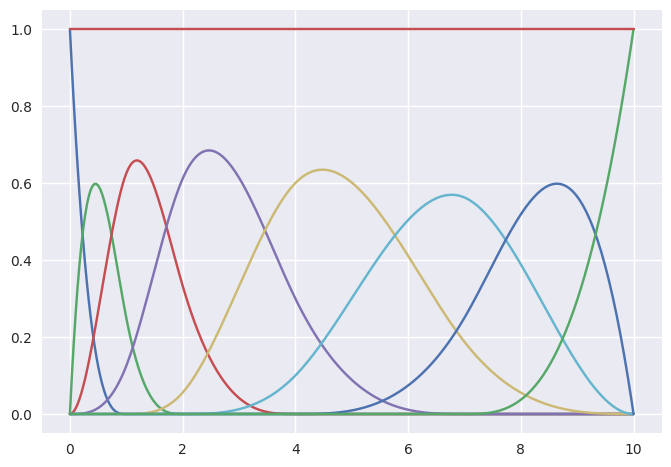

In [15]:
tt = np.linspace(0, 10, 300)

for i in range(len(spline_elems)):
  plt.plot(tt, [spline_elems[i](t) for t in tt])

plt.plot(tt, [sum([spline_elems[i](t) for i in range(len(spline_elems))]) for t in tt])

[0.58841954 0.0368581  0.56877587 0.90542364 0.97616997 0.07860797
 0.08883956 0.51931611]


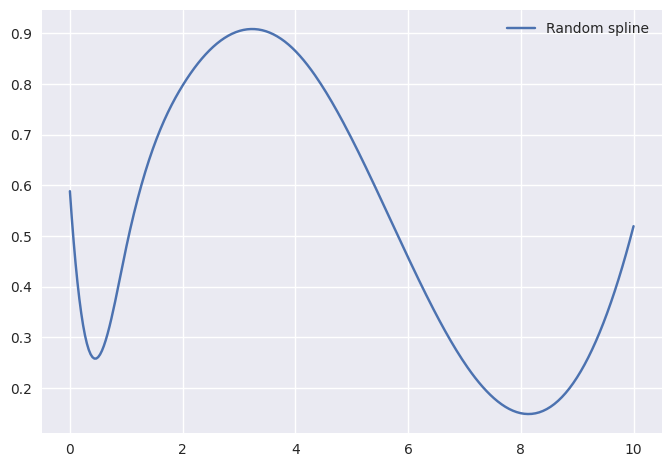

In [16]:
weights = np.random.rand(len(spline_elems))
print(weights)

plt.plot(tt, [sum([weights[i] * spline_elems[i](t) for i in range(len(spline_elems))]) for t in tt], label="Random spline")

plt.legend()

In [17]:
def b_spline_1st_derivative(spline: callable = None, order: int = None, knots: list[float] = None, h: float = 1e-6) -> callable:
  if spline is None:
    spline = b_spline_elem(order, knots)
  return lambda x: (spline(x + h / 2) - spline(x - h / 2)) / h


def b_spline_2nd_derivative(spline: callable = None, order: int = None, knots: list[float] = None, h: float = 1e-6) -> callable:
  if spline is None:
    spline = b_spline_elem(order, knots)
  return lambda x: (spline(x + h) - 2 * spline(x) + spline(x - h)) / (h ** 2)

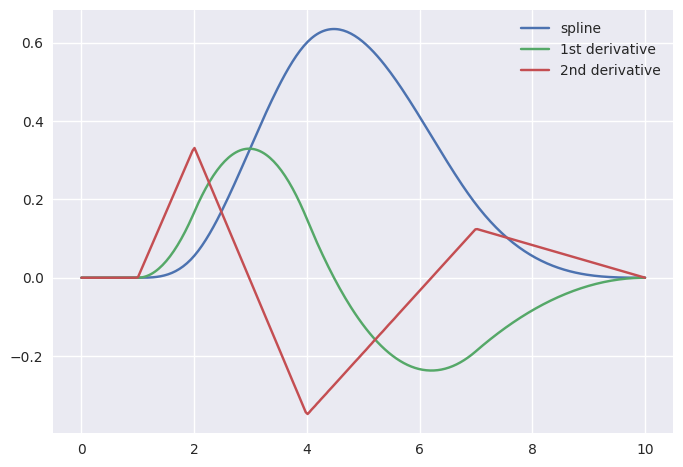

In [18]:
plt.plot(tt, [spline_elems[4](t) for t in tt], label="spline")
plt.plot(tt, [b_spline_1st_derivative(spline_elems[4])(t) for t in tt], label="1st derivative")
plt.plot(tt, [b_spline_2nd_derivative(spline_elems[4])(t) for t in tt], label="2nd derivative")

plt.legend()
plt.show()

### Anderson interpolation

In [19]:
model = Anderson(yields, maturities, (L, S, i))

/home/kasper/GIT/quantpy/quantpy/math/curve/Anderson.py:128: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  L_ij = quad(func, m_0, m_n, epsabs=1e-6, epsrel=1e-6)


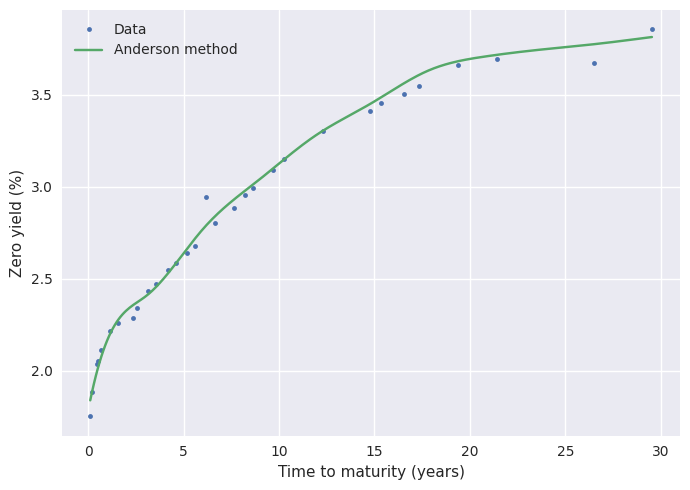

In [20]:
tt = np.linspace(maturities.min(), maturities.max(), 300)

fig = plt.figure(figsize=(7, 5))

plt.plot(maturities, yields * 100, '.', label="Data")
plt.plot(tt, model(tt) * 100, label="Anderson method")
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

plt.legend()
fig.tight_layout()

plt.show()

## Multidynamic model

The new proposed term-structure model is implemented in the `MultidynamicModel` class. In order to benefit from the form the proposed model, extend the curve points to full(er) yield structure. To avoid overfitting a lower convergence tolerance is utilized.

In [21]:
model = MultidynamicModel(yields, maturities, init_params=[0.4, 0.04, 0.02, 0.02, 0.01, 0.005], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=100_000)

In [22]:
print(model.params)

{'tau': np.float64(0.056319768874787776), 'beta_0': np.float64(0.020793568025414315), 'beta_1': np.float64(-0.007592518300149643), 'beta_2': np.float64(3.3270833315376415e-06), 'beta_3': np.float64(0.0012628633672666298), 'beta_4': np.float64(-2.3399289572496465e-05)}


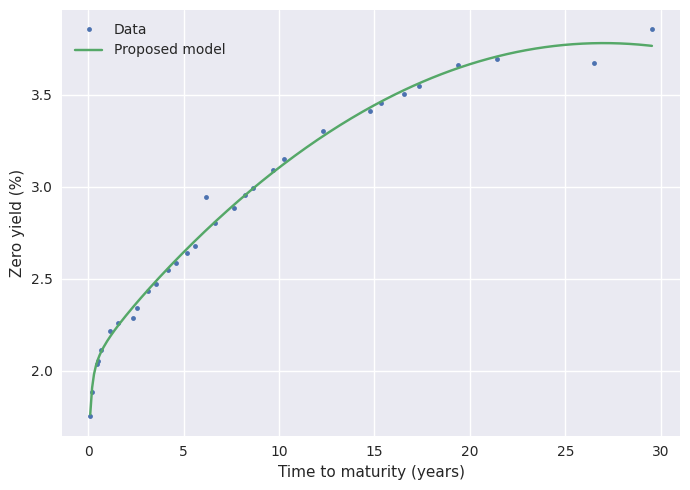

In [23]:
tt = np.linspace(maturities.min(), maturities.max(), 300)

fig = plt.figure(figsize=(7, 5))

plt.plot(maturities, yields * 100, '.', label="Data")
plt.plot(tt, model(tt) * 100, label="Proposed model")
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

plt.legend()
fig.tight_layout()

plt.show()